In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/akkharaphonc/elective5/district_mueang_lamphun__16_subdistrict_mueang_nga__polling_unit_13__ส.ส.5-18.csv
/kaggle/input/datasets/akkharaphonc/elective5/district_ban_thi__02_subdistrict_huai_yap__polling_unit_16__ส.ส.5-18 (บช).csv
/kaggle/input/datasets/akkharaphonc/elective5/district_mae_tha__05_subdistrict_tha_thung_luang__polling_unit_1__ส.ส.5-18.csv
/kaggle/input/datasets/akkharaphonc/elective5/advance_outside_district_and_overseas__ส.ส.5-17-ชุดที่ 6.csv
/kaggle/input/datasets/akkharaphonc/elective5/district_mae_tha__02_subdistrict_municipality_tha_sop_chai__polling_unit_2__ส.ส.5-18 (บช).csv
/kaggle/input/datasets/akkharaphonc/elective5/advance_outside_district_and_overseas__ส.ส.5-17-ชุดที่ 9.csv
/kaggle/input/datasets/akkharaphonc/elective5/district_mueang_lamphun__05_subdistrict_wiang_yong__polling_unit_9__ส.ส.5-18.csv
/kaggle/input/datasets/akkharaphonc/elective5/district_mueang_lamphun__16_subdistrict_mueang_nga__polling_unit_17__ส.ส.5-18 (บช).csv
/kaggle/i

In [3]:
# =========================================
# BLOCK 1 : IMPORT LIBRARIES
# =========================================

import os
import re
import glob

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# =========================================
# BLOCK 2 : LOAD ALL FILES
# =========================================

import os
import glob
import pandas as pd

# recursive search ทุก csv
all_files = glob.glob(
    '/kaggle/input/**/*.csv',
    recursive=True
)

print("TOTAL CSV FILES :", len(all_files))

# filter เฉพาะ elective5
all_files = [
    f for f in all_files
    if 'elective5' in f.lower()
]

print("ELECTIVE5 FILES :", len(all_files))

# preview
for f in all_files[:5]:
    print(f)

all_data = []

for file in all_files:

    try:
        df = pd.read_csv(file)

        # save source path
        df['source_file'] = file

        all_data.append(df)

    except Exception as e:
        print("ERROR :", file)
        print(e)

# merge
data = pd.concat(all_data, ignore_index=True)

print("FINAL DATA SHAPE :", data.shape)

display(data.head())

TOTAL CSV FILES : 640
ELECTIVE5 FILES : 640
/kaggle/input/datasets/akkharaphonc/elective5/district_mueang_lamphun__16_subdistrict_mueang_nga__polling_unit_13__ส.ส.5-18.csv
/kaggle/input/datasets/akkharaphonc/elective5/district_ban_thi__02_subdistrict_huai_yap__polling_unit_16__ส.ส.5-18 (บช).csv
/kaggle/input/datasets/akkharaphonc/elective5/district_mae_tha__05_subdistrict_tha_thung_luang__polling_unit_1__ส.ส.5-18.csv
/kaggle/input/datasets/akkharaphonc/elective5/advance_outside_district_and_overseas__ส.ส.5-17-ชุดที่ 6.csv
/kaggle/input/datasets/akkharaphonc/elective5/district_mae_tha__02_subdistrict_municipality_tha_sop_chai__polling_unit_2__ส.ส.5-18 (บช).csv
FINAL DATA SHAPE : (18261, 3)


,party,score,source_file
0,ประชาชน,311,/kaggle/input/datasets/akkharaphonc/elective5/...
1,ไทยก้าวใหม่,2,/kaggle/input/datasets/akkharaphonc/elective5/...
2,ภูมิใจไทย,49,/kaggle/input/datasets/akkharaphonc/elective5/...
3,ประชาธิปัตย์,16,/kaggle/input/datasets/akkharaphonc/elective5/...
4,เศรษฐกิจ,25,/kaggle/input/datasets/akkharaphonc/elective5/...


In [5]:
# =========================================
# BLOCK 3 : EXTRACT METADATA
# =========================================

import re
import os

def extract_metadata(path):

    filename = os.path.basename(path).lower()

    # district
    district_match = re.search(
        r'district_(.*?)__',
        filename
    )

    # subdistrict
    subdistrict_match = re.search(
        r'subdistrict_(.*?)__',
        filename
    )

    # polling unit
    polling_match = re.search(
        r'polling_unit_(\d+)',
        filename
    )

    # election type
    if 'ส.ส.' in filename:
        election_type = 'mp_election'
    else:
        election_type = 'unknown'

    district = (
        district_match.group(1)
        if district_match else 'unknown'
    )

    subdistrict = (
        subdistrict_match.group(1)
        if subdistrict_match else 'unknown'
    )

    polling_unit = (
        polling_match.group(1)
        if polling_match else 'unknown'
    )

    return pd.Series([
        district,
        subdistrict,
        polling_unit,
        election_type
    ])

data[
    [
        'district',
        'subdistrict',
        'polling_unit',
        'election_type'
    ]
] = data['source_file'].apply(extract_metadata)

display(
    data[
        [
            'district',
            'subdistrict',
            'polling_unit',
            'election_type'
        ]
    ].head()
)

,district,subdistrict,polling_unit,election_type
0,mueang_lamphun,mueang_nga,13,mp_election
1,mueang_lamphun,mueang_nga,13,mp_election
2,mueang_lamphun,mueang_nga,13,mp_election
3,mueang_lamphun,mueang_nga,13,mp_election
4,mueang_lamphun,mueang_nga,13,mp_election


In [6]:
# =========================================
# BLOCK 4 : CLEAN DATA
# =========================================

# remove missing
data = data.dropna(subset=['party', 'score'])

# convert score
data['score'] = pd.to_numeric(data['score'], errors='coerce')

data = data.dropna(subset=['score'])

print(data.shape)

(18261, 7)


In [7]:
# =========================================
# BLOCK 5 : FEATURE ENGINEERING
# =========================================

from sklearn.preprocessing import LabelEncoder

# -----------------------------
# CLEAN DATA TYPE
# -----------------------------

data['party'] = data['party'].astype(str)

data['district'] = data['district'].astype(str)

data['subdistrict'] = data['subdistrict'].astype(str)

data['election_type'] = (
    data['election_type'].astype(str)
)

# -----------------------------
# LABEL ENCODING
# -----------------------------

le_party = LabelEncoder()
le_election = LabelEncoder()
le_district = LabelEncoder()
le_subdistrict = LabelEncoder()

# encode party
data['party_encoded'] = (
    le_party.fit_transform(data['party'])
)

# encode election type
data['election_encoded'] = (
    le_election.fit_transform(data['election_type'])
)

# encode district
data['district_encoded'] = (
    le_district.fit_transform(data['district'])
)

# encode subdistrict
data['subdistrict_encoded'] = (
    le_subdistrict.fit_transform(data['subdistrict'])
)

# -----------------------------
# NUMERIC FEATURES
# -----------------------------

data['polling_unit'] = pd.to_numeric(
    data['polling_unit'],
    errors='coerce'
)

data['score'] = pd.to_numeric(
    data['score'],
    errors='coerce'
)

# remove invalid rows
data = data.dropna(subset=['score'])

# -----------------------------
# FEATURE SET
# -----------------------------

features = [
    'party_encoded',
    'score',
    'district_encoded',
    'subdistrict_encoded',
    'polling_unit',
    'election_encoded'
]

X = data[features].fillna(0)

print(X.shape)

display(X.head())

(18261, 6)


,party_encoded,score,district_encoded,subdistrict_encoded,polling_unit,election_encoded
0,50,311,3,6,13.0,0
1,132,2,3,6,13.0,0
2,80,49,3,6,13.0,0
3,53,16,3,6,13.0,0
4,117,25,3,6,13.0,0


In [8]:
# =========================================
# BLOCK 6 : NORMALIZATION
# =========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(18261, 6)


In [9]:
# =========================================
# BLOCK 7 : ANOMALY DETECTION
# =========================================

model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)

model.fit(X_scaled)

# anomaly score
data['anomaly_score'] = model.decision_function(X_scaled)

# prediction
data['anomaly'] = model.predict(X_scaled)

# convert
data['anomaly'] = data['anomaly'].map({
    1: 0,
    -1: 1
})

data.head()

,party,score,source_file,district,subdistrict,polling_unit,election_type,party_encoded,election_encoded,district_encoded,subdistrict_encoded,anomaly_score,anomaly
0,ประชาชน,311,/kaggle/input/datasets/akkharaphonc/elective5/...,mueang_lamphun,mueang_nga,13.0,mp_election,50,0,3,6,-0.029512,1
1,ไทยก้าวใหม่,2,/kaggle/input/datasets/akkharaphonc/elective5/...,mueang_lamphun,mueang_nga,13.0,mp_election,132,0,3,6,0.143843,0
2,ภูมิใจไทย,49,/kaggle/input/datasets/akkharaphonc/elective5/...,mueang_lamphun,mueang_nga,13.0,mp_election,80,0,3,6,0.100064,0
3,ประชาธิปัตย์,16,/kaggle/input/datasets/akkharaphonc/elective5/...,mueang_lamphun,mueang_nga,13.0,mp_election,53,0,3,6,0.137378,0
4,เศรษฐกิจ,25,/kaggle/input/datasets/akkharaphonc/elective5/...,mueang_lamphun,mueang_nga,13.0,mp_election,117,0,3,6,0.126822,0


In [10]:
# =========================================
# BLOCK 8 : TOP ANOMALIES
# =========================================

top_anomaly = data.sort_values(
    by='anomaly_score'
).head(20)

top_anomaly[
    [
        'party',
        'score',
        'district',
        'polling_unit',
        'anomaly_score'
    ]
]

,party,score,district,polling_unit,anomaly_score
4958,ประชาชน,5050,and_overseas,NaN,-0.133128
11779,ประชาชน,588,and_overseas,NaN,-0.128146
8836,ประชาชน,564,and_overseas,NaN,-0.127897
6304,ประชาชน,572,and_overseas,NaN,-0.127897
14843,ประชาชน,536,and_overseas,NaN,-0.127153
10932,ประชาชน,543,and_overseas,NaN,-0.127153
14121,ประชาชน,544,and_overseas,NaN,-0.127153
4155,ประชาชน,545,and_overseas,NaN,-0.127153
9944,ประชาชน,549,and_overseas,NaN,-0.127153
2641,ประชาชน,538,and_overseas,NaN,-0.127153


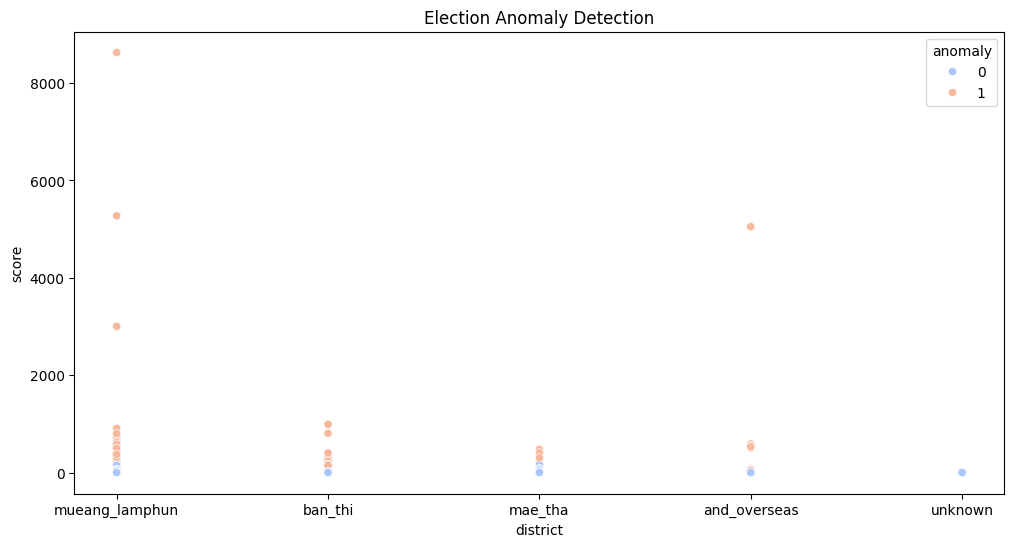

In [11]:
# =========================================
# BLOCK 9A : ANOMALY GRAPH
# =========================================

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=data,
    x='district',
    y='score',
    hue='anomaly',
    palette='coolwarm'
)

plt.title("Election Anomaly Detection")

plt.show()

In [12]:
# =========================================
# THAI FONT FIX
# =========================================

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ใช้ font ที่รองรับไทย
plt.rcParams['font.family'] = 'DejaVu Sans'

# แก้ minus sign เพี้ยน
plt.rcParams['axes.unicode_minus'] = False

In [13]:
# =========================================
# PARTY NORMALIZATION PIPELINE
# =========================================

def normalize_party(party):

    party = str(party).strip()

    # -----------------------------
    # INVALID VALUES
    # -----------------------------

    invalid_values = [
        '-', '☑'
    ]

    if party in invalid_values:
        return 'invalid'

    # remove pure numbers
    if party.isdigit():
        return 'invalid'

    # thai digits
    thai_digits = '๐๑๒๓๔๕๖๗๘๙'

    if all(c in thai_digits for c in party):
        return 'invalid'

    # -----------------------------
    # PEOPLE PARTY
    # -----------------------------

    if 'ประชาชน' in party or 'ปรมาชน' in party:
        return 'people_party'

    # -----------------------------
    # PHEU THAI
    # -----------------------------

    if 'เพื่อไทย' in party:
        return 'pheu_thai'

    # -----------------------------
    # BHUMJAITHAI
    # -----------------------------

    if 'ภูมิใจไทย' in party:
        return 'bhumjaithai'

    # -----------------------------
    # DEMOCRAT
    # -----------------------------

    if 'ประชาธิปัตย์' in party:
        return 'democrat_party'

    # -----------------------------
    # UNITED THAI NATION
    # -----------------------------

    if 'รวมไทยสร้างชาติ' in party:
        return 'united_thai_nation'

    # -----------------------------
    # MOVE FORWARD
    # -----------------------------

    if 'ก้าวไกล' in party:
        return 'move_forward'

    # -----------------------------
    # THAI PROGRESS
    # -----------------------------

    if 'ไทยก้าวใหม่' in party:
        return 'thai_progress'

    # -----------------------------
    # FUSION
    # -----------------------------

    if (
        'ฟิวชัน' in party or
        'ฟิวซัน' in party or
        'พิวซัน' in party or
        'พิวจัน' in party or
        'พืชชัน' in party
    ):
        return 'fusion_party'

    # -----------------------------
    # KLA THAM
    # -----------------------------

    if (
        'กล้าธรรม' in party or
        'กลาธรรม' in party or
        'กล่าวจรม' in party or
        'กล้วยธรรม' in party or
        'กล้ำธรรม' in party or
        'คล้ายธรรม' in party
    ):
        return 'kla_tham'

    # -----------------------------
    # VISION MAI
    # -----------------------------

    if (
        'วิช' in party or
        'วิชัย' in party or
        'วิชช' in party
    ):
        return 'vision_new'

    # -----------------------------
    # THAI KAO NA
    # -----------------------------

    if 'ไทยก้าวหน้า' in party:
        return 'thai_kao_na'

    # -----------------------------
    # THAI WIN
    # -----------------------------

    if 'ไทยชนะ' in party:
        return 'thai_win'

    # -----------------------------
    # SERI RUAM THAI
    # -----------------------------

    if 'เสรีรวมไทย' in party:
        return 'seri_ruam_thai'

    # -----------------------------
    # fallback
    # -----------------------------

    return 'other_party'


# apply normalization
data['party_clean'] = (
    data['party']
    .apply(normalize_party)
)

# preview
print(
    data[
        ['party', 'party_clean']
    ].head(50)
)

                  party         party_clean
0               ประชาชน        people_party
1           ไทยก้าวใหม่       thai_progress
2             ภูมิใจไทย         bhumjaithai
3          ประชาธิปัตย์      democrat_party
4              เศรษฐกิจ         other_party
5              กล้าธรรม            kla_tham
6       รวมไทยสร้างชาติ  united_thai_nation
7              เพื่อไทย           pheu_thai
8            เสรีรวมไทย      seri_ruam_thai
9           วิชชั่นใหม่          vision_new
10         ไทยทรัพย์ทวี         other_party
11         เพื่อชาติไทย         other_party
12                 ใหม่         other_party
13             มิติใหม่         other_party
14             รวมใจไทย         other_party
15      รวมไทยสร้างชาติ  united_thai_nation
16                พลวัต         other_party
17      ประชาธิปไตยใหม่         other_party
18             เพื่อไทย           pheu_thai
19         ทางเลือกใหม่         other_party
20             เศรษฐกิจ         other_party
21           เสรีรวมไทย      ser

In [14]:
# =========================================
# SHOW ALL UNIQUE PARTY NAMES
# =========================================

unique_parties = (
    data['party']
    .astype(str)
    .unique()
)

for i, party in enumerate(unique_parties):
    print(f"{i+1}. {party}")

1. ประชาชน
2. ไทยก้าวใหม่
3. ภูมิใจไทย
4. ประชาธิปัตย์
5. เศรษฐกิจ
6. กล้าธรรม
7. รวมไทยสร้างชาติ
8. เพื่อไทย
9. เสรีรวมไทย
10. วิชชั่นใหม่
11. ไทยทรัพย์ทวี
12. เพื่อชาติไทย
13. ใหม่
14. มิติใหม่
15. รวมใจไทย
16. พลวัต
17. ประชาธิปไตยใหม่
18. ทางเลือกใหม่
19. รวมพลังประชาชน
20. ท้องที่ไทย
21. อนาคตไทย
22. พลังเพื่อไทย
23. ไทยชนะ
24. พลังสังคมใหม่
25. สังคมประชาธิปไตยไทย
26. ฟิวชัน
27. ไทรวมพลัง
28. ก้าวอิสระ
29. ปวงชนไทย
30. เพื่อชีวิตใหม่
31. คลองไทย
32. ไทยก้าวหน้า
33. ไทยภักดี
34. แรงงานสร้างชาติ
35. ประชากรไทย
36. ครูไทยเพื่อประชาชน
37. ประชาชาติ
38. สร้างอนาคตไทย
39. รักชาติ
40. ไทยพร้อม
41. พลังธรรมใหม่
42. กรีน
43. ไทยธรรม
44. แผ่นดินธรรม
45. พลังประชารัฐ
46. โอกาสใหม่
47. เป็นธรรม
48. ประชาไทย
49. ไทยสร้างไทย
50. ประชาอาสาชาติ
51. พร้อม
52. เครือข่ายชาวนาแห่งประเทศไทย
53. ไทยพิทักษ์ธรรม
54. ความหวังใหม่
55. ไทยรวมไทย
56. เพื่อบ้านเมือง
57. พลังไทยรักชาติ
58. ☑
59. พิวซัน
60. -
61. วิชช์ขันใหม่
62. วิชชันใหม่
63. วิชช์ใหม่
64. วิชช์ชั่นใหม่
65. ก้าวลิสรณ
66. วิชช์ชนใหม่
67. วิชช

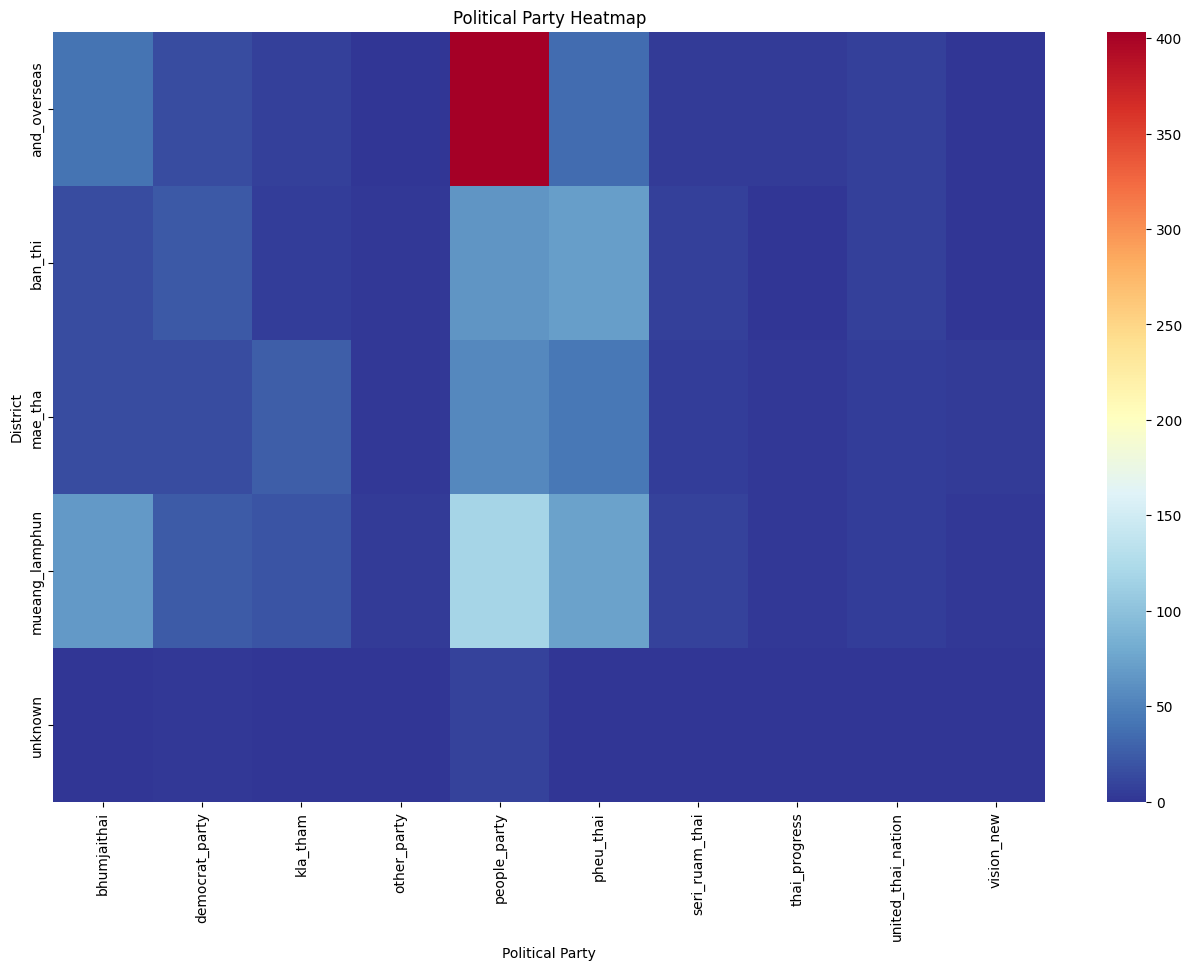

In [15]:
# =========================================
# BLOCK 9B : PARTY HEATMAP
# =========================================

# remove invalid party
heatmap_df = data[
    data['party_clean'] != 'invalid'
]

# optional:
# keep only top parties
top_parties = (
    heatmap_df['party_clean']
    .value_counts()
    .head(10)
    .index
)

heatmap_df = heatmap_df[
    heatmap_df['party_clean'].isin(top_parties)
]

# create pivot table
heatmap_data = heatmap_df.pivot_table(
    values='score',
    index='district',
    columns='party_clean',
    aggfunc='mean'
)

# plot
plt.figure(figsize=(16,10))

sns.heatmap(
    heatmap_data,
    cmap='RdYlBu_r'
)

plt.title("Political Party Heatmap")

plt.xlabel("Political Party")
plt.ylabel("District")

plt.show()

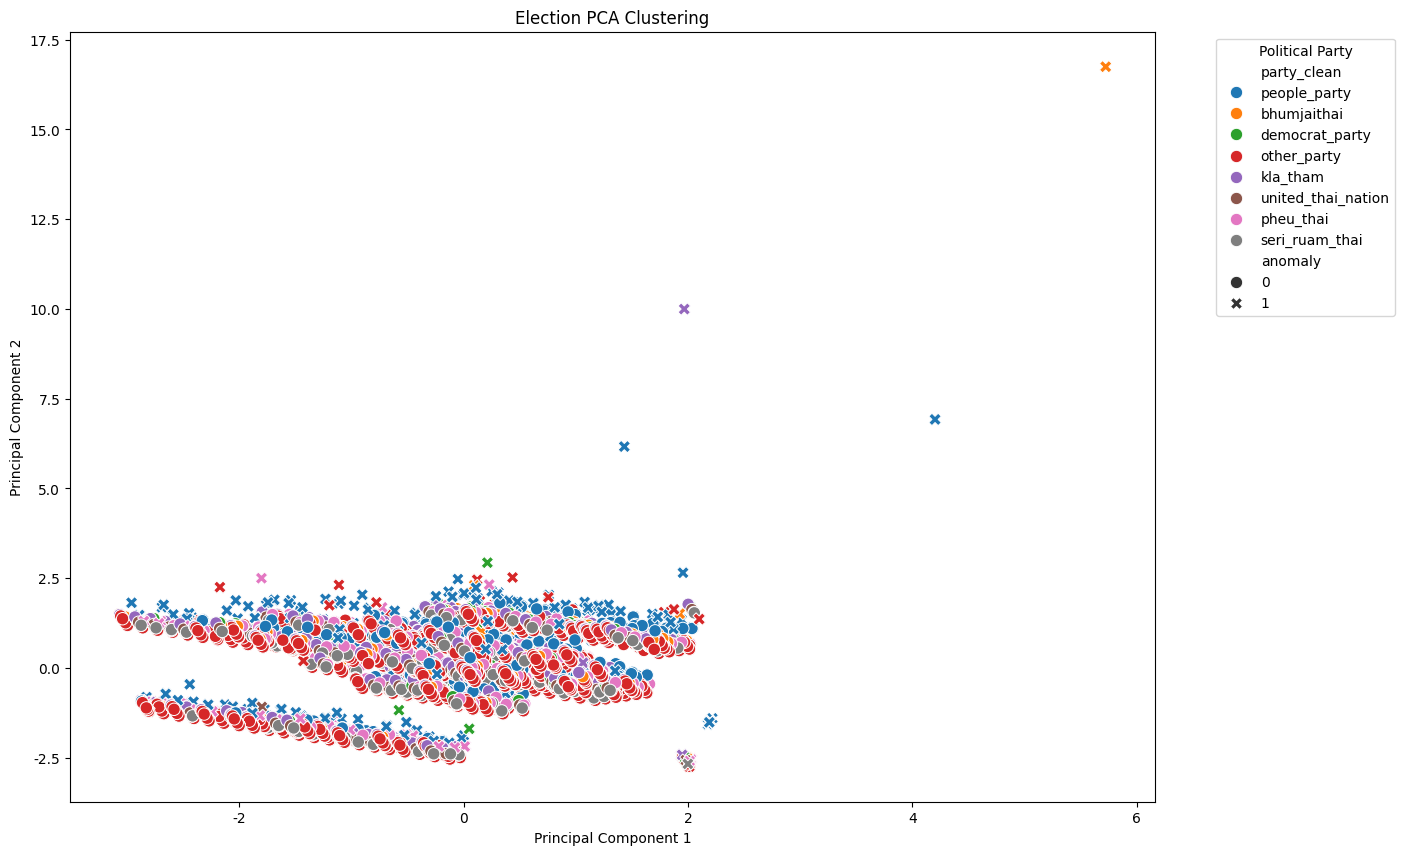

In [16]:
# =========================================
# BLOCK 9C : PCA CLUSTERING
# =========================================

from sklearn.decomposition import PCA

# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# save PCA result
data['PCA1'] = X_pca[:,0]
data['PCA2'] = X_pca[:,1]

# remove invalid
pca_df = data[
    data['party_clean'] != 'invalid'
]

# keep top parties only
top_parties = (
    pca_df['party_clean']
    .value_counts()
    .head(8)
    .index
)

pca_df = pca_df[
    pca_df['party_clean'].isin(top_parties)
]

# plot
plt.figure(figsize=(14,10))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='party_clean',
    style='anomaly',
    s=80
)

plt.title("Election PCA Clustering")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    title='Political Party',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

In [17]:
# =========================================
# EXPORT CLEANED DATA
# =========================================

data.to_csv(
    '/kaggle/working/cleaned_election_data.csv',
    index=False
)

print("Export Complete")

Export Complete
